In [1]:
# import dbof.dataset_creation.zarr_dataset as zarr_dataset
# import dbof.io.filesystems as filesystems

In [2]:
import llc_cutout_dataloader.cutouts_dataset as cutouts_dataset

In [3]:
import torch
import matplotlib.pyplot as plt
from dask.distributed import Client

In [6]:
cutouts_dataloader = cutouts_dataset.get_cutout_loader(subset=True, subsample_per_chunk = 64, num_sample_chunks = 1, n_workers=8, batch_size=64)

C:\Users\Jake Tallman\PycharmProjects\DBOF_Representation_Learning\.venv\Lib\site-packages\distributed\node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 52707 instead
  warnings.warn(


<Client: 'tcp://127.0.0.1:52710' processes=8 threads=16, memory=31.10 GiB>
nrp link url : https://jupyterhub-west.nrp-nautilus.io/hub/user-redirect/proxy/52707/status


C:\Users\Jake Tallman\PycharmProjects\DBOF_Representation_Learning\.venv\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


torch.Size([54, 8, 64, 64])
tensor([-5.5189e-08, -2.6846e-06, -2.2076e-08,  0.0000e+00, -6.0708e-09,
        -4.0840e-08, -8.2784e-09,  1.9747e-06])
tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000])


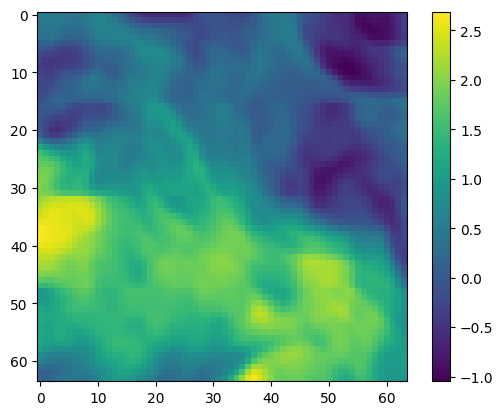

In [5]:
for batch in cutouts_dataloader:
    print(batch.shape)
    img = batch[0][3]
    plt.imshow(img)
    plt.colorbar()

    print(torch.mean(batch, dim=[0,2,3] ))
    print(torch.std(batch, dim=[0,2,3] ))

    break

In [ ]:
# # follow link for a progress bar in following steps
# client = Client(n_workers=8)
#
# port = client.scheduler_info()["services"]["dashboard"]
# # For nrp link is :
# #https://jupyterhub-west.nrp-nautilus.io/hub/user-redirect/proxy/{port}/status
# print(f"url : https://jupyterhub-west.nrp-nautilus.io/hub/user-redirect/proxy/{port}/status")

In [4]:
# bucket = "dbof" #data_cfg["bucket"]
# folder = "native_grid_dbof_training_data"
# s3_endpoint = "https://s3-west.nrp-nautilus.io"
# feature_channels = ['Eta', 'Salt', 'Theta', 'U', 'V', 'W', 'relative_vorticity', 'log_gradb']
# run_id = "big_run_00"
#
# fs, fs_synch = filesystems.create_s3_filesystems(s3_endpoint)
#
# reader = zarr_dataset.ZarrDatasetReader(
#     bucket=bucket,
#     folder=folder,
#     run_id=run_id,
#     dataset_name="dataset_creation.zarr",
#     fs=fs
# )

In [ ]:
images_da, ids_da, valid_mask_da = reader.full_dataset_as_dask()

In [5]:
loader = dbof_dataloader.make_dbof_cutout_dataloader(reader, client, batch_size=64, transform=None, subset=10240)

C:\Users\Jake Tallman\PycharmProjects\DBOF_Representation_Learning\.venv\Lib\site-packages\distributed\node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 57040 instead
  warnings.warn(


Loading Images into memory (10240, 8, 64, 64) ...
Loading ids into memory (10240,) ...


In [ ]:
# todo get cuda working

In [6]:
dino = torch.hub.load("facebookresearch/dinov2", "dinov2_vits14")  # small
dino.eval().cuda()

Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to C:\Users\Jake Tallman/.cache\torch\hub\main.zip


C:\Users\Jake Tallman/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
C:\Users\Jake Tallman/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
C:\Users\Jake Tallman/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vits14/dinov2_vits14_pretrain.pth" to C:\Users\Jake Tallman/.cache\torch\hub\checkpoints\dinov2_vits14_pretrain.pth


100%|██████████| 84.2M/84.2M [00:03<00:00, 24.8MB/s]


AssertionError: Torch not compiled with CUDA enabled